In [0]:
# Caminho para a tabela Delta Lake na camada Silver
delta_table_path_silver = "/Volumes/workspace/default/tables/cardio_silver"

df_silver = spark.read.format("delta").load(delta_table_path_silver)

df_silver.printSchema()
df_silver.show(5)


root
 |-- id: integer (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: integer (nullable = true)
 |-- height: integer (nullable = true)
 |-- weight: double (nullable = true)
 |-- ap_hi: integer (nullable = true)
 |-- ap_lo: integer (nullable = true)
 |-- cholesterol: integer (nullable = true)
 |-- gluc: integer (nullable = true)
 |-- smoke: integer (nullable = true)
 |-- alco: integer (nullable = true)
 |-- active: integer (nullable = true)
 |-- cardio: integer (nullable = true)
 |-- age_years: integer (nullable = true)
 |-- gender_mapped: string (nullable = true)
 |-- cholesterol_mapped: string (nullable = true)
 |-- gluc_mapped: string (nullable = true)

+----+-----+------+------+------+-----+-----+-----------+----+-----+----+------+------+---------+-------------+-------------------+-----------+
|  id|  age|gender|height|weight|ap_hi|ap_lo|cholesterol|gluc|smoke|alco|active|cardio|age_years|gender_mapped| cholesterol_mapped|gluc_mapped|
+----+-----+------+------+---

In [0]:

df_silver.describe().show()

+-------+------------------+------------------+------------------+------------------+------------------+------------------+-----------------+------------------+------------------+-------------------+-------------------+------------------+-------------------+------------------+-------------+------------------+---------------+
|summary|                id|               age|            gender|            height|            weight|             ap_hi|            ap_lo|       cholesterol|              gluc|              smoke|               alco|            active|             cardio|         age_years|gender_mapped|cholesterol_mapped|    gluc_mapped|
+-------+------------------+------------------+------------------+------------------+------------------+------------------+-----------------+------------------+------------------+-------------------+-------------------+------------------+-------------------+------------------+-------------+------------------+---------------+
|  count|          

In [0]:
%pip install matplotlib seaborn

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


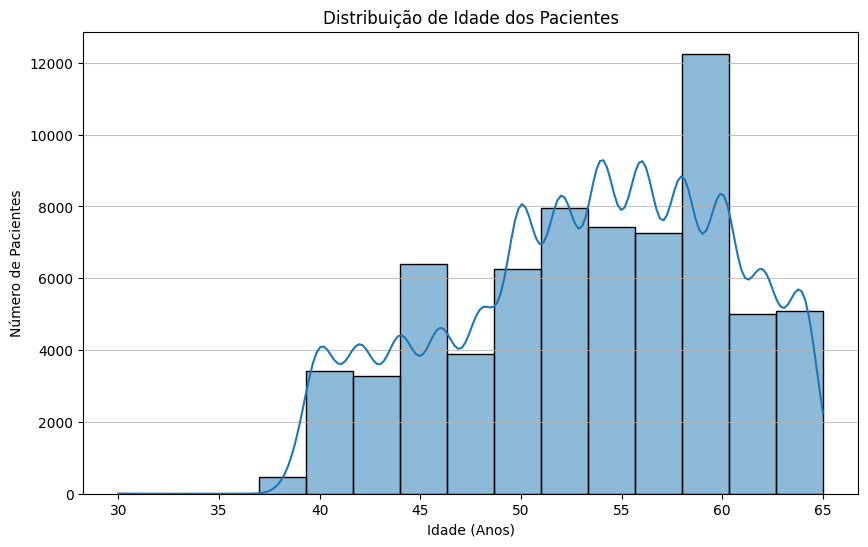

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

df_pandas = df_silver.toPandas()

plt.figure(figsize=(10, 6))
sns.histplot(df_pandas["age_years"], bins=15, kde=True)
plt.title("Distribuição de Idade dos Pacientes")
plt.xlabel("Idade (Anos)")
plt.ylabel("Número de Pacientes")
plt.grid(axis='y', alpha=0.75)
plt.show()


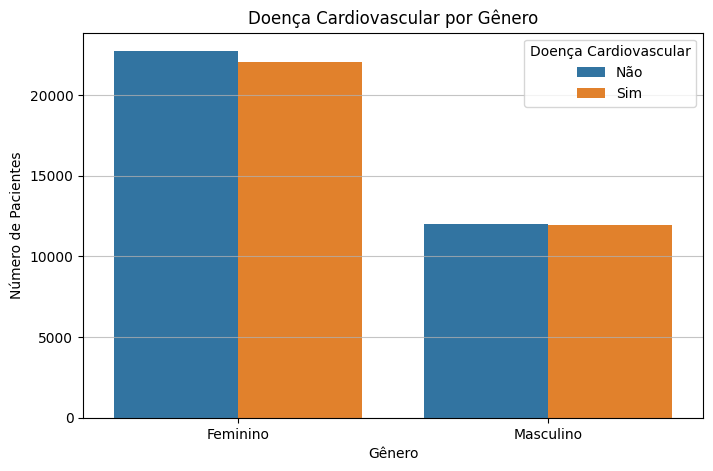

In [0]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_pandas, x="gender_mapped", hue="cardio")
plt.title("Doença Cardiovascular por Gênero")
plt.xlabel("Gênero")
plt.ylabel("Número de Pacientes")
plt.legend(title="Doença Cardiovascular", labels=["Não", "Sim"])
plt.grid(axis='y', alpha=0.75)
plt.show()
